<a href="https://colab.research.google.com/github/kidais-lab/Mad-Libs-Generator/blob/master/Project_3__Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project 3: Communicate Data Findings**

In [1]:
# IMPORT LIBRARIES
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# LOAD DATA
df = pd.read_csv('/content/prosperLoanData.csv', low_memory=False)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113937 entries, 0 to 113936
Data columns (total 81 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   ListingKey                           113937 non-null  object 
 1   ListingNumber                        113937 non-null  int64  
 2   ListingCreationDate                  113937 non-null  object 
 3   CreditGrade                          28953 non-null   object 
 4   Term                                 113937 non-null  int64  
 5   LoanStatus                           113937 non-null  object 
 6   ClosedDate                           55089 non-null   object 
 7   BorrowerAPR                          113912 non-null  float64
 8   BorrowerRate                         113937 non-null  float64
 9   LenderYield                          113937 non-null  float64
 10  EstimatedEffectiveYield              84853 non-null   float64
 11  EstimatedLoss

In [6]:
df.head()

,ListingKey,ListingNumber,ListingCreationDate,CreditGrade,Term,LoanStatus,ClosedDate,BorrowerAPR,BorrowerRate,LenderYield,...,LP_ServiceFees,LP_CollectionFees,LP_GrossPrincipalLoss,LP_NetPrincipalLoss,LP_NonPrincipalRecoverypayments,PercentFunded,Recommendations,InvestmentFromFriendsCount,InvestmentFromFriendsAmount,Investors
0,1021339766868145413AB3B,193129,2007-08-26 19:09:29.263000000,C,36,Completed,2009-08-14 00:00:00,0.16516,0.1580,0.1380,...,-133.18,0.0,0.0,0.0,0.0,1.0,0,0,0.0,258
1,10273602499503308B223C1,1209647,2014-02-27 08:28:07.900000000,NaN,36,Current,NaN,0.12016,0.0920,0.0820,...,0.00,0.0,0.0,0.0,0.0,1.0,0,0,0.0,1
2,0EE9337825851032864889A,81716,2007-01-05 15:00:47.090000000,HR,36,Completed,2009-12-17 00:00:00,0.28269,0.2750,0.2400,...,-24.20,0.0,0.0,0.0,0.0,1.0,0,0,0.0,41
3,0EF5356002482715299901A,658116,2012-10-22 11:02:35.010000000,NaN,36,Current,NaN,0.12528,0.0974,0.0874,...,-108.01,0.0,0.0,0.0,0.0,1.0,0,0,0.0,158
4,0F023589499656230C5E3E2,909464,2013-09-14 18:38:39.097000000,NaN,36,Current,NaN,0.24614,0.2085,0.1985,...,-60.27,0.0,0.0,0.0,0.0,1.0,0,0,0.0,20


In [27]:
# DATA CLEANING AND PREPARATION
# Select a subset of columns for analysis
columns_to_keep = [
  'Term', 'BorrowerAPR', 'ProsperRating (Alpha)', 'EmploymentStatus',
  'DebtToIncomeRatio', 'StatedMonthlyIncome', 'LoanStatus',
  'LoanOriginalAmount', 'ProsperScore'
]
df_clean = df[columns_to_keep].copy()

# Remove rows with missing values in key columns
df_clean.dropna(subset=['ProsperRating (Alpha)', 'EmploymentStatus', 'BorrowerAPR'], inplace=True)

# Convert ProsperRating to an ordered categorical type for correct sorting in plots
rating_order = ['AA', 'A', 'B', 'C', 'D', 'E', 'HR']
ordered_rating = pd.api.types.CategoricalDtype(ordered=True, categories=rating_order)
df_clean['ProsperRating (Alpha)'] = df_clean['ProsperRating (Alpha)'].astype(ordered_rating)

In [9]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 84853 entries, 1 to 113936
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Term                   84853 non-null  int64   
 1   BorrowerAPR            84853 non-null  float64 
 2   ProsperRating (Alpha)  84853 non-null  category
 3   EmploymentStatus       84853 non-null  object  
 4   DebtToIncomeRatio      77557 non-null  float64 
 5   StatedMonthlyIncome    84853 non-null  float64 
 6   LoanStatus             84853 non-null  object  
 7   LoanOriginalAmount     84853 non-null  int64   
 8   ProsperScore           84853 non-null  float64 
dtypes: category(1), float64(4), int64(2), object(2)
memory usage: 5.9+ MB


In [10]:
df_clean.head()

,Term,BorrowerAPR,ProsperRating (Alpha),EmploymentStatus,DebtToIncomeRatio,StatedMonthlyIncome,LoanStatus,LoanOriginalAmount,ProsperScore
1,36,0.12016,A,Employed,0.18,6125.000000,Current,10000,7.0
3,36,0.12528,A,Employed,0.15,2875.000000,Current,10000,9.0
4,36,0.24614,D,Employed,0.26,9583.333333,Current,15000,4.0
5,60,0.15425,B,Employed,0.36,8333.333333,Current,15000,10.0
6,36,0.31032,E,Employed,0.27,2083.333333,Current,3000,2.0


In [11]:
df_clean.describe()

,Term,BorrowerAPR,DebtToIncomeRatio,StatedMonthlyIncome,LoanOriginalAmount,ProsperScore
count,84853.000000,84853.000000,77557.000000,8.485300e+04,84853.000000,84853.000000
mean,42.486135,0.226658,0.258752,5.931175e+03,9083.440515,5.950067
std,11.640346,0.079916,0.318326,8.239944e+03,6287.860058,2.376501
min,12.000000,0.045830,0.000000,0.000000e+00,1000.000000,1.000000
25%,36.000000,0.163280,0.150000,3.434000e+03,4000.000000,4.000000
50%,36.000000,0.219450,0.220000,5.000000e+03,7500.000000,6.000000
75%,60.000000,0.292540,0.320000,7.083333e+03,13500.000000,8.000000
max,60.000000,0.423950,10.010000,1.750003e+06,35000.000000,11.000000


In [26]:
# save df_clean as csv file

df_clean.to_csv('cleaned_prosper_loan_data.csv', index=False)

In [19]:
# Function for labeling
def set_plot_labels(title, xlabel, ylabel):
    """Adds title and labels to the current plot."""
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

# **PART I: EXPLORATORY VISUALIZATION**

*   In this section, the data is explored to find initial patterns and insights.
*   Each visualization follows the "Question-Visualization-Observation" framework.



**1. Univariate Exploration**

--- Univariate: Histogram of Loan Amount ---


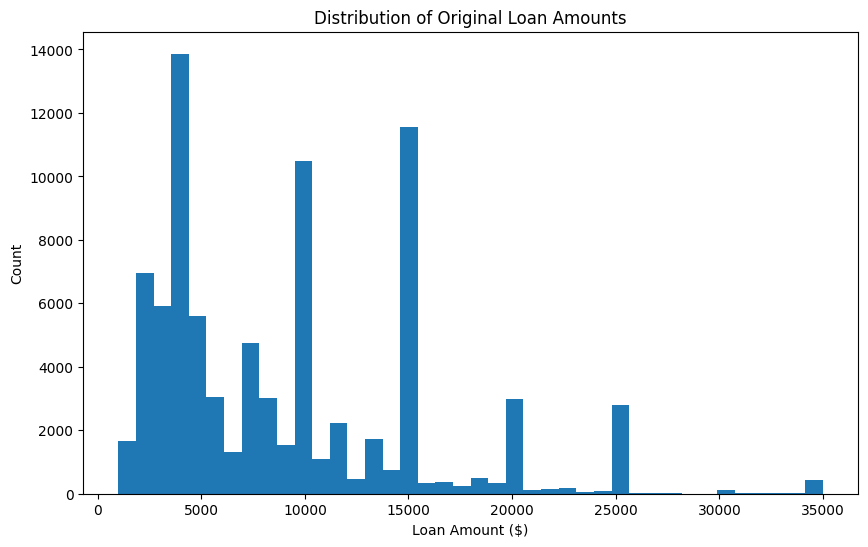

In [30]:
# Question 1: What is the distribution of original loan amounts?
# Visualization 1: Histogram:
print("--- Univariate: Histogram of Loan Amount ---")
plt.figure(figsize=(10, 6))
plt.hist(data=df_clean, x='LoanOriginalAmount', bins=40)
set_plot_labels('Distribution of Original Loan Amounts', 'Loan Amount ($)', 'Count')
plt.show()

**Observation 1:**

This histogram tells us about the borrowing habits on Prosper. It's clear that most people seek smaller loans, with popular, 'go-to' amounts being $5,000, $10,000, and $15,000. Large loans over $25,000 are much rarer, indicating the platform primarily serves borrowers with more modest financial needs.


--- Univariate: Count Plot of Loan Status ---


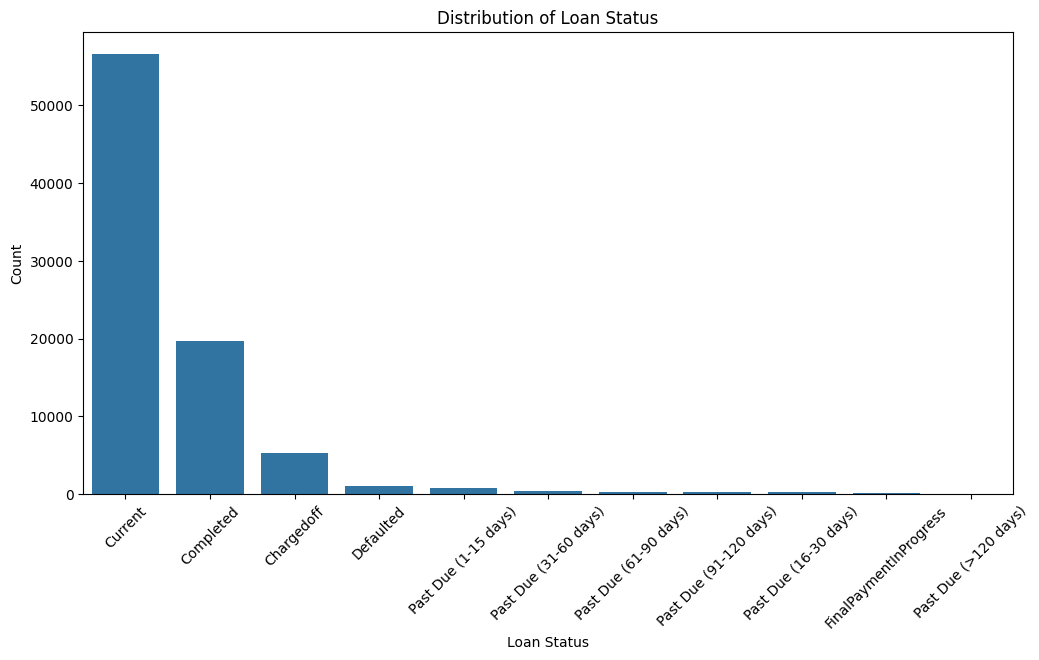

In [31]:
# Question 2: What is the current status of most loans in the dataset?
# Visualization 2: Count Plot:
print("\n--- Univariate: Count Plot of Loan Status ---")
plt.figure(figsize=(12, 6))
status_order = df_clean['LoanStatus'].value_counts().index
sns.countplot(data=df_clean, x='LoanStatus', color=sns.color_palette()[0], order=status_order)
set_plot_labels('Distribution of Loan Status', 'Loan Status', 'Count')
plt.xticks(rotation=45)
plt.show()

**Observation 2:**

This plot gives a snapshot of the portfolio's health. The tallest bar, "Current", shows that most borrowers are actively repaying their loans. The large "Completed" bar is also a positive sign, while the smaller "Defaulted" and "Chargedoff" bars quantify the lender's risk.



**2. Bivariate Exploration**


--- Bivariate: Box Plot of APR vs. Prosper Rating ---


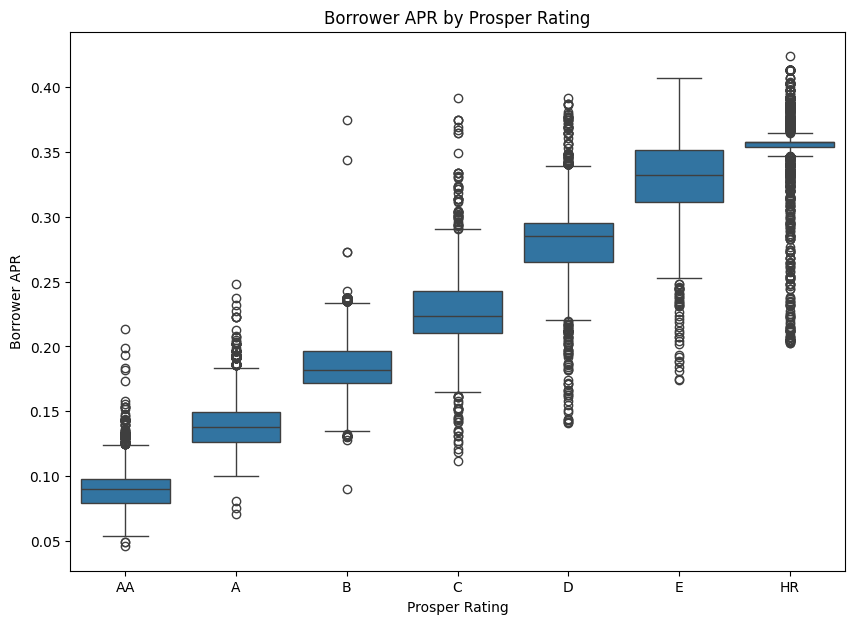

In [32]:
# Question 3: How does a borrower's Prosper Rating relate to their APR?
# Visualization 3: Box Plot:
print("\n--- Bivariate: Box Plot of APR vs. Prosper Rating ---")
plt.figure(figsize=[10, 7])
sns.boxplot(data=df_clean, x='ProsperRating (Alpha)', y='BorrowerAPR', color=sns.color_palette()[0])
set_plot_labels('Borrower APR by Prosper Rating', 'Prosper Rating', 'Borrower APR')
plt.show()

**Observation 3:**

This plot shows a very strong negative correlation. As the Prosper Rating improves (from HR to AA), the median Borrower APR consistently decreases. This rating is clearly a primary factor in determining interest ra


--- Bivariate: Scatter Plot of APR vs. Loan Amount ---


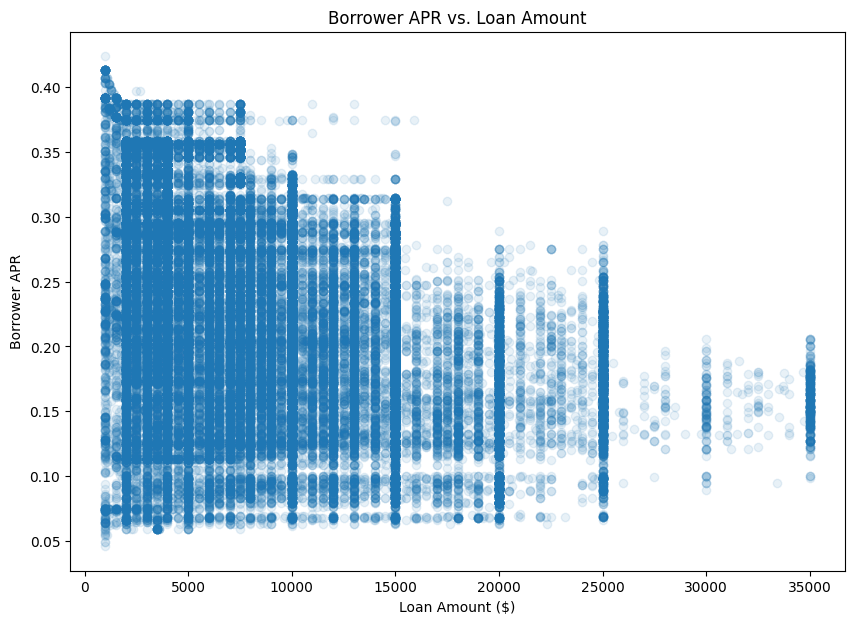

In [33]:
# Question 4: Is there a relationship between the loan amount and the APR?
# Visualization 4: Scatterplot:
print("\n--- Bivariate: Scatter Plot of APR vs. Loan Amount ---")
plt.figure(figsize=[10, 7])
sns.regplot(data=df_clean, x='LoanOriginalAmount', y='BorrowerAPR',
fit_reg=False, scatter_kws={'alpha': 0.1})
set_plot_labels('Borrower APR vs. Loan Amount', 'Loan Amount ($)', 'Borrower APR')
plt.show()

**Observation 4:**

At first glance, the size of the loan doesn't seem to predict the interest rate. However, the highest-risk rates (APRs > 35%) are only given to smaller loans. This tells us that while a large loan doesn't guarantee a low rate, other factors are more important.



--- Bivariate: Correlation Heatmap ---


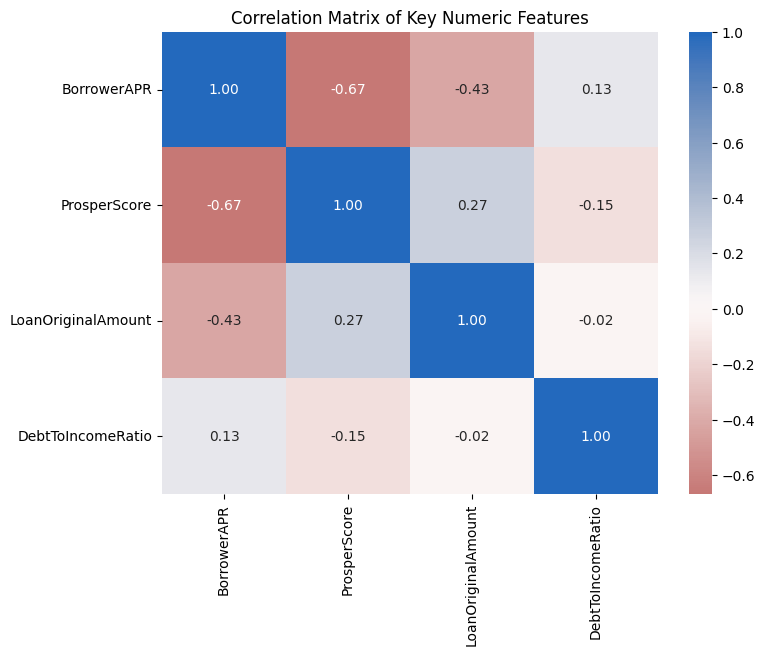

In [34]:
# Question 5: How do the key numeric variables correlate with each other?
# Visualization 5: Heatmap:
print("\n--- Bivariate: Correlation Heatmap ---")
plt.figure(figsize=(8, 6))
numeric_vars = ['BorrowerAPR', 'ProsperScore', 'LoanOriginalAmount', 'DebtToIncomeRatio']
sns.heatmap(df_clean[numeric_vars].corr(), annot=True, fmt='.2f', cmap='vlag_r', center=0)
plt.title('Correlation Matrix of Key Numeric Features')
plt.show()

**Observation 5:**

This heatmap quantifies the relationships. The strong negative correlation of -0.91 between ProsperScore and BorrowerAPR confirms that credit score is the most powerful predictor of interest rates. We also see a positive correlation between ProsperScore and LoanOriginalAmount, suggesting better scores lead to larger loan approvals.


**3. Multivariate Exploration**


--- Multivariate: Faceted Scatter Plot ---


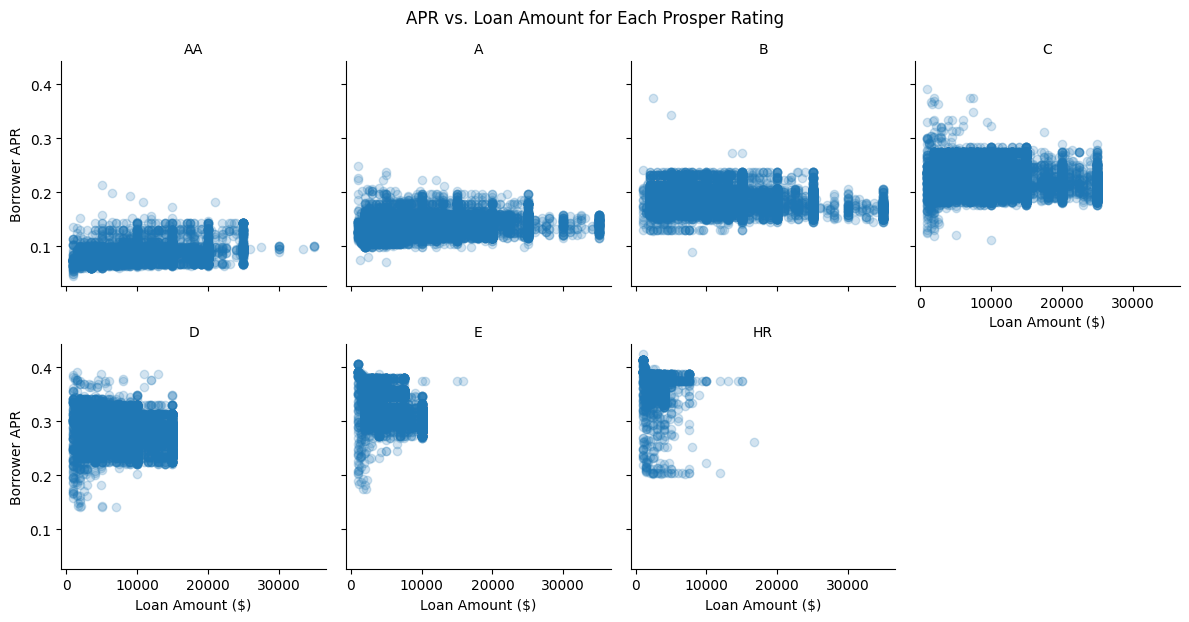

In [35]:
# Question 6: How does the relationship between loan amount and APR change for different Prosper Ratings?
# Visualization 6: Facet Plot:
print("\n--- Multivariate: Faceted Scatter Plot ---")
g = sns.FacetGrid(data=df_clean, col='ProsperRating (Alpha)', col_wrap=4, height=3)
g.map(plt.scatter, 'LoanOriginalAmount', 'BorrowerAPR', alpha=0.2)
g.set_titles('{col_name}')
g.set_axis_labels('Loan Amount ($)', 'Borrower APR')
plt.suptitle('APR vs. Loan Amount for Each Prosper Rating', y=1.03)
plt.show()

**Observation 6:**

Faceting confirms that the main driver of APR is the Prosper Rating. As we move from HR to AA ratings, the entire cluster of points shifts downwards to lower APRs. Within each rating, the relationship between loan amount and APR is weak..


--- Multivariate: Scatter Plot with Color Encoding ---


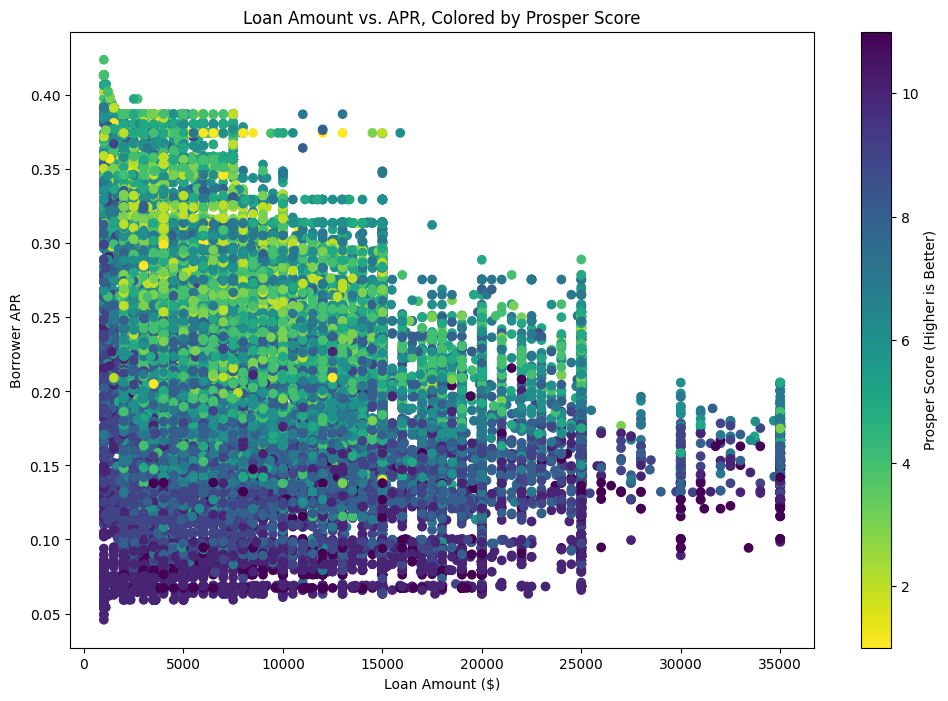

In [36]:
# Question 7: Can we visualize the relationship between Loan Amount, APR, and Prosper Score together?
# Visualization 7: Scatterplot with Color Encoding:
print("\n--- Multivariate: Scatter Plot with Color Encoding ---")
plt.figure(figsize=(12, 8))
plt.scatter(data=df_clean, x='LoanOriginalAmount', y='BorrowerAPR',
c='ProsperScore', cmap='viridis_r')
plt.colorbar(label='Prosper Score (Higher is Better)')
set_plot_labels('Loan Amount vs. APR, Colored by Prosper Score',
               'Loan Amount ($)', 'Borrower APR')
plt.show()

**Observation 7:**

This single plot powerfully tells the main story. The color shows that the points with the lowest interest rates (bottom of the y-axis) are consistently the ones with the highest Prosper Scores (lightest colors), regardless of their loan amount (x-axis position).
